# Customer Churn

---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
df["Contract"].nunique()

3

In [8]:
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [10]:
df = df.drop("customerID", axis=1)

In [11]:
df[df["tenure"] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df = df.drop(df[df["tenure"] == 0].index)

In [13]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [16]:
yes_no_features = []
for column in df.columns:
    unique_values = df[column].unique()
    if 'Yes' in unique_values and 'No' in unique_values:
        yes_no_features.append(column)

print("Features with 'Yes' or 'No' values:")
print(yes_no_features)

Features with 'Yes' or 'No' values:
['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']


In [17]:
for col in yes_no_features:
  print(f"{col}: {df[col].unique()}")

Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
PaperlessBilling: ['Yes' 'No']
Churn: ['No' 'Yes']


### Target Variable

In [18]:
churn_dist = df["Churn"].value_counts()
churn_dist

,count
Churn,
No,5163
Yes,1869


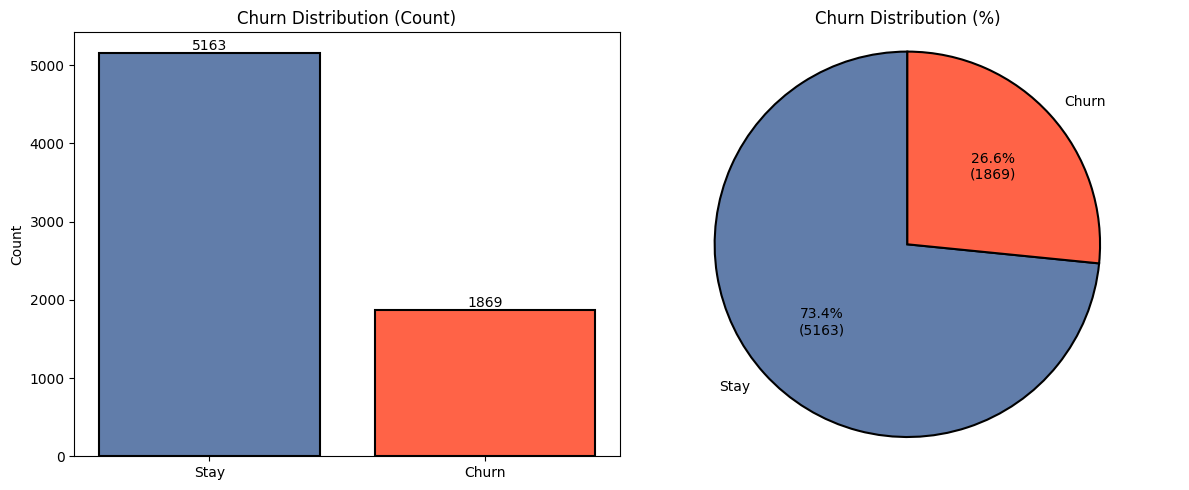

In [19]:
total = churn_dist.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(
    ['Stay', 'Churn'],
    churn_dist.values,
    color=['#617DAA', 'tomato'],
    edgecolor='black',
    linewidth=1.5
)
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Count')

for i, v in enumerate(churn_dist.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# Pie chart
axes[1].pie(
    churn_dist.values,
    labels=['Stay', 'Churn'],
    colors=['#617DAA', 'tomato'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5},
    startangle=90,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * total / 100))})'
)
axes[1].set_title('Churn Distribution (%)')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

### Demographic Features

In [20]:
demographic_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

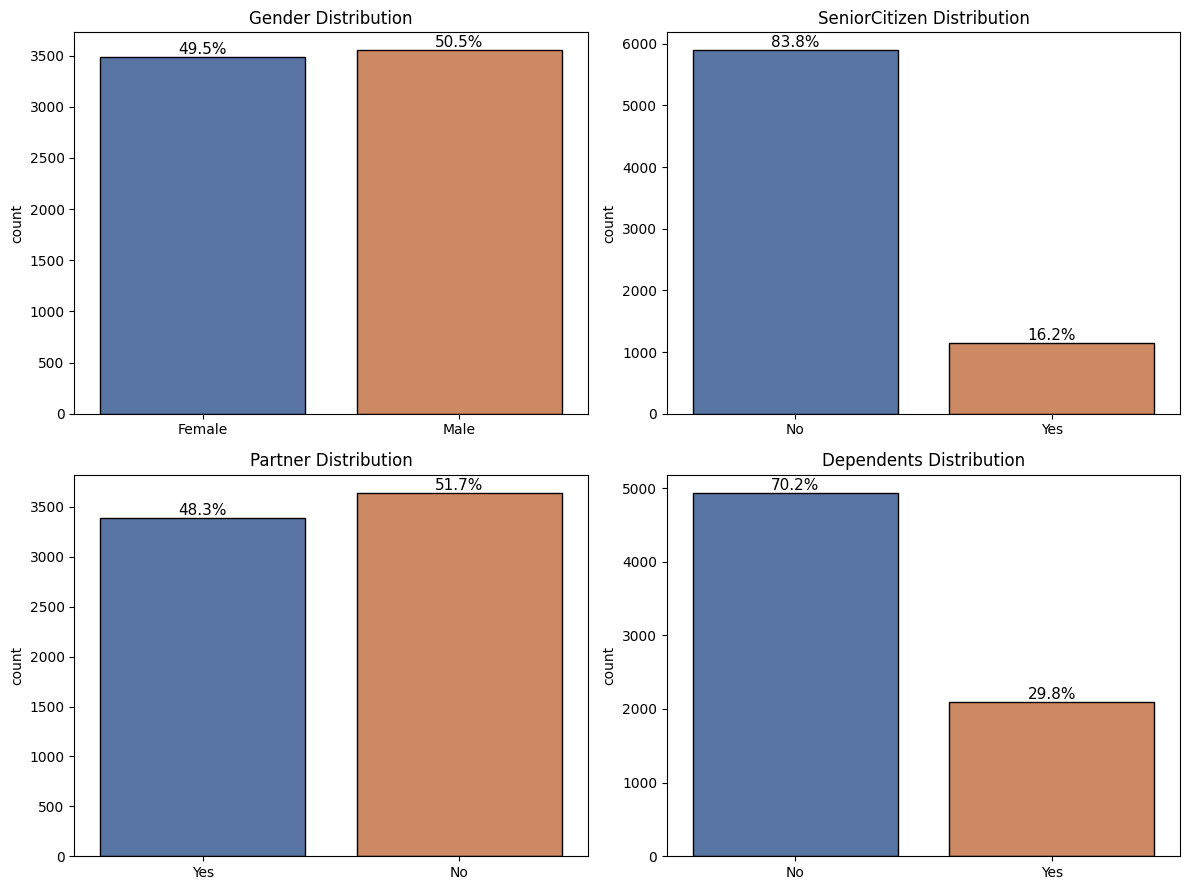

In [21]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 9)
)

axes = axes.flatten()


for ax, feature in zip(axes, demographic_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="deep",
        edgecolor="black",
        legend=False,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.1f}%"
                for x in container.datavalues],
            fontsize=11
        )

    ax.set_title(f"{feature.capitalize()} Distribution")
    ax.set_xlabel('')



    if feature == "SeniorCitizen":
        ax.set_title(f"{feature} Distribution")

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No", "Yes"])

plt.tight_layout()
plt.show()

### Service Features

In [22]:
service_features = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

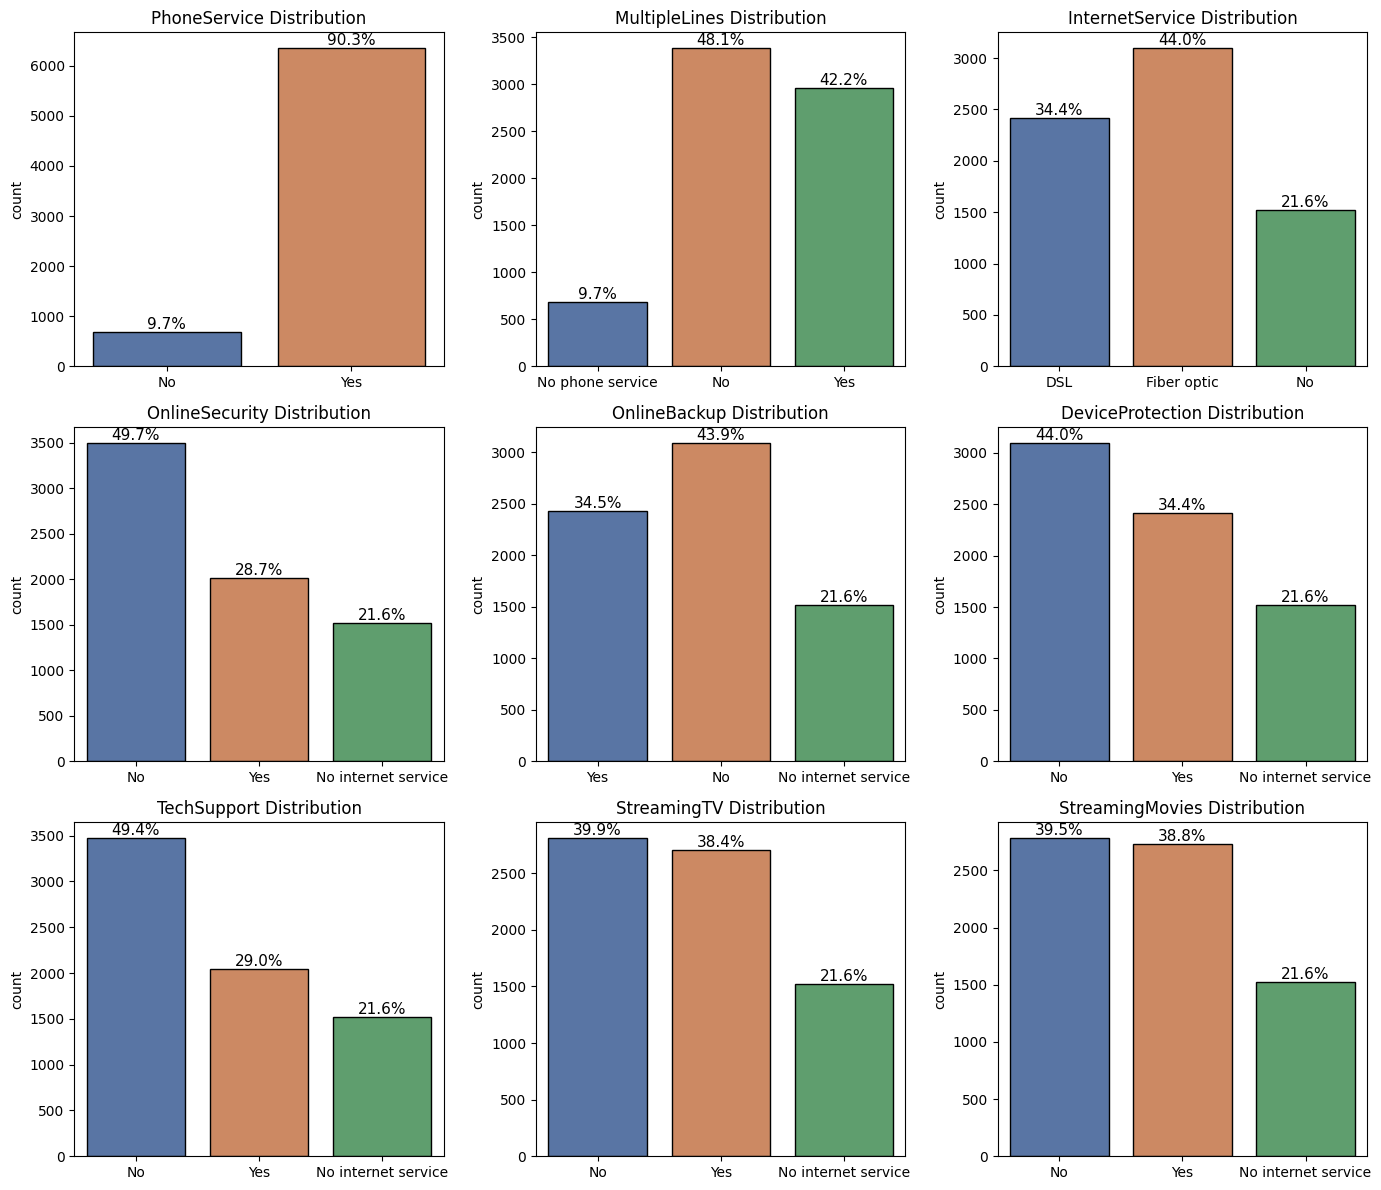

In [71]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(14, 12)
)

axes = axes.flatten()

for ax, feature in zip(axes, service_features):
    sns.countplot(
        data=df,
        x=feature,
        hue=feature,
        palette="deep",
        edgecolor="black",
        legend=False,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[
                f"{x / len(df) * 100:.1f}%"
                for x in container.datavalues
            ],
            fontsize=11
        )

    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Customer Relationship

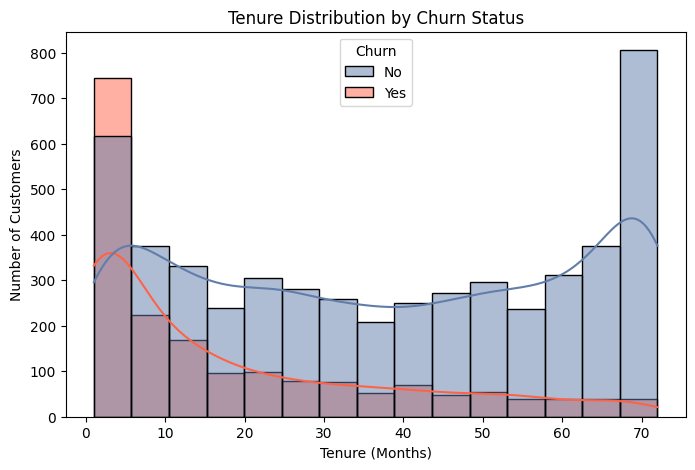

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    edgecolor='black',
    palette=['#617DAA', 'tomato'],
    multiple='layer'
)

plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')

plt.show()

/tmp/ipykernel_1492/3858821766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


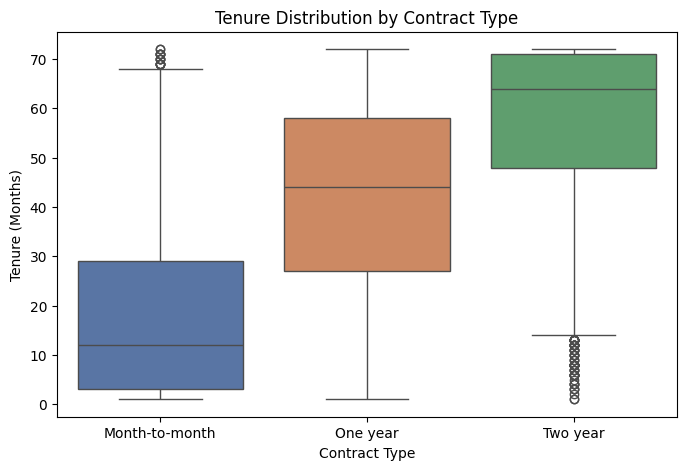

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Contract',
    y='tenure',
    palette="deep"
)

plt.title('Tenure Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Tenure (Months)')
plt.show()

/tmp/ipykernel_1492/427923757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


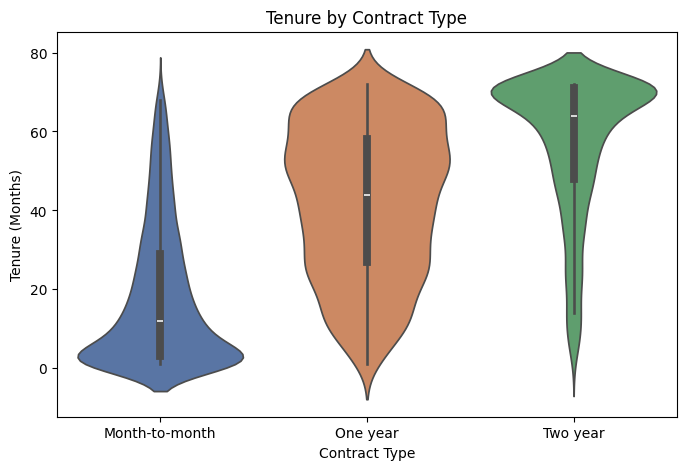

In [26]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x='Contract',
    y='tenure',
    palette='deep'
)

plt.title('Tenure by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Tenure (Months)')
plt.show()

### Billing & Payment

In [27]:
billing_payment = [
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges"
]

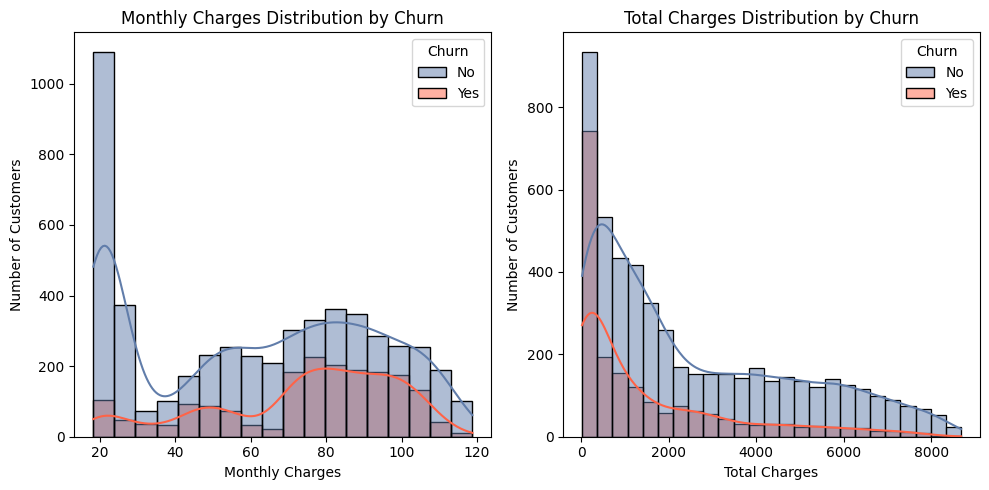

In [28]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5)
)

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    kde=True,
    edgecolor="black",
    palette=['#617DAA', 'tomato'],
    alpha=0.5,
    ax=ax[0]
)

sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    kde=True,
    edgecolor="black",
    palette=['#617DAA', 'tomato'],
    alpha=0.5,
    ax=ax[1]
)

ax[0].set_title("Monthly Charges Distribution by Churn")
ax[0].set_xlabel("Monthly Charges")
ax[0].set_ylabel("Number of Customers")

ax[1].set_title("Total Charges Distribution by Churn")
ax[1].set_xlabel("Total Charges")
ax[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

##Contract and Churn

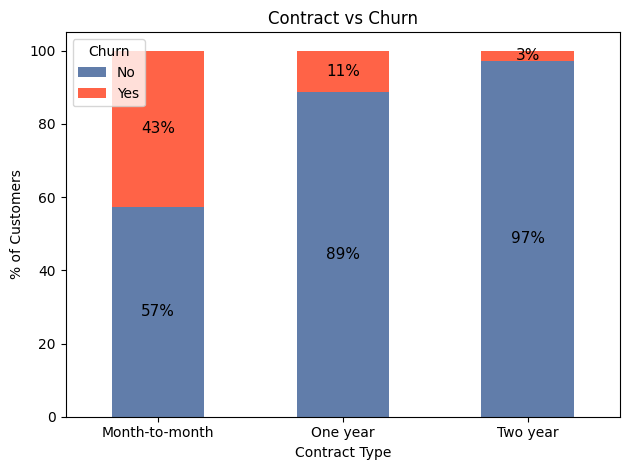

In [29]:
cross = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100
ax = cross.plot(
    kind="bar",
    stacked=True,
    color=sns.color_palette(['#617DAA', 'tomato'])
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{x:.0f}%"
            for x in container.datavalues
        ],
        label_type="center",
        fontsize=11
    )
ax.set_title("Contract vs Churn")
ax.set_xlabel("Contract Type")
ax.set_ylabel("% of Customers")
ax.legend(title="Churn",labels=["No", "Yes"])

plt.xticks(rotation=0)
plt.tight_layout();

##Monthly Charges and Churn

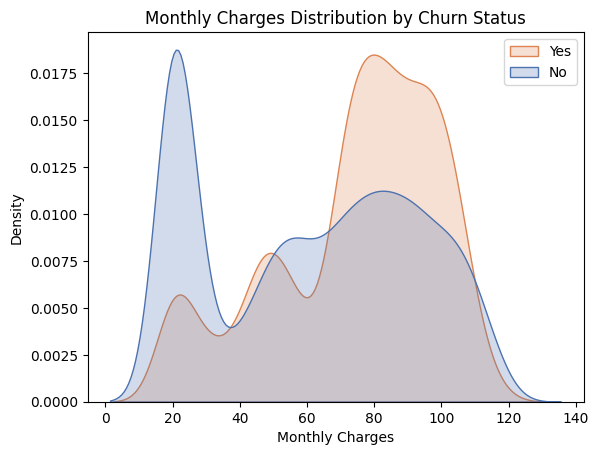

In [30]:
sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    palette="deep",
    common_norm=False,
    fill=True,
)
plt.title("Monthly Charges Distribution by Churn Status")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.legend(["Yes", "No"]);

##Total Charges and Churn

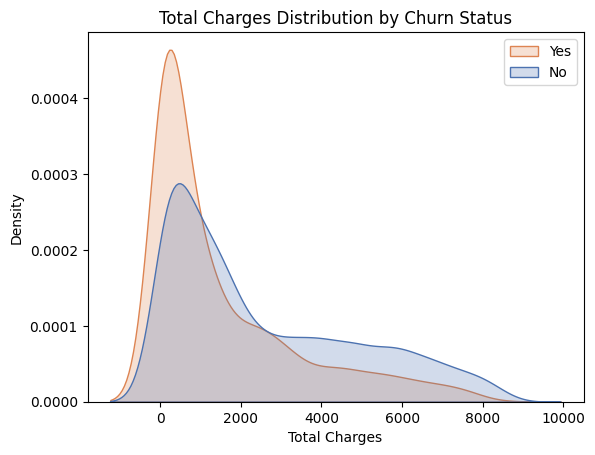

In [31]:
sns.kdeplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    palette="deep",
    common_norm=False,
    fill=True,
);
plt.title("Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Density")
plt.legend(["Yes", "No"]);

## Tenure and Churn

/tmp/ipykernel_1492/166274248.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


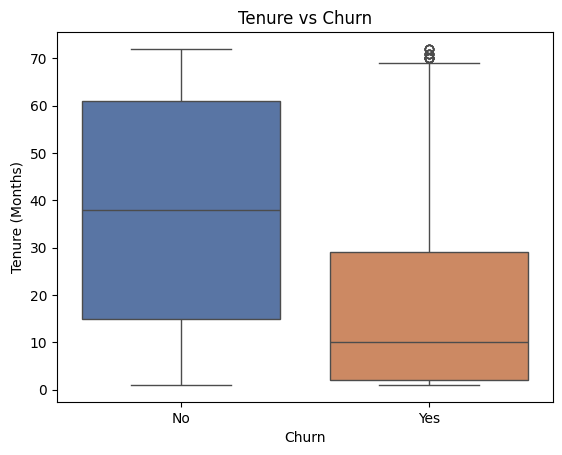

In [32]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="deep",
    legend=False
);

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.xticks(ticks=[0, 1], labels=["No", "Yes"]);

## Heatmap

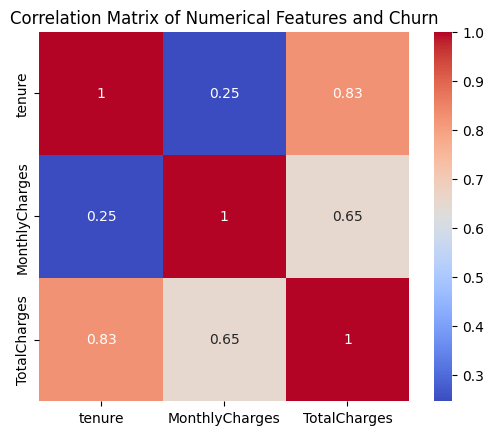

In [73]:
numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
corr_matrix = df[numeric_columns].corr()

sns.heatmap(
    corr_matrix,
    square=True,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features and Churn");

## Categorical Columns Encoding

### Binary Mapping

In [34]:
df_encoded = df.copy()

In [35]:
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

In [36]:
for feature in yes_no_cols:
    df_encoded[feature] = df_encoded[feature].map({ 'No': 0, 'Yes': 1})

In [37]:
df_encoded["gender"].unique()

array(['Female', 'Male'], dtype=object)

In [38]:
df_encoded["gender"] = df_encoded["gender"].map({
    "Male": 0,
    "Female": 1
})

In [39]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_cols:
    df_encoded[col] = df_encoded[col].map({"No": 0, "No internet service": 0, "Yes": 1,})

In [40]:
df_encoded["MultipleLines"] = df_encoded["MultipleLines"].map({"No phone service": 0,"No": 0,"Yes": 1})

In [41]:
for col in ["InternetService", "Contract", "PaymentMethod"]:
    print(f"{col}: {df_encoded[col].unique()}")

InternetService: ['DSL' 'Fiber optic' 'No']
Contract: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


### Label Encoding

In [42]:
df_encoded["Contract"] = df_encoded["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})

### One-Hot Encoding

In [43]:
cat_cols = df_encoded.select_dtypes(include='object').columns

df_encoded = pd.get_dummies(
    df_encoded,
    columns=cat_cols,
    drop_first=True
)

In [44]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [45]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null   int64  
 11  Streaming

In [46]:
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,1,29.85,29.85,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,0,0,0,1,0,56.95,1889.50,0,0,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,0,0,0,0,1,53.85,108.15,1,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,1,0,0,1,0,42.30,1840.75,0,0,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,0,0,0,0,1,70.70,151.65,1,1,0,0,1,0


## Modeling

### Problem Classification
Binary classification : predicting `Churn` (0 = stay, 1 = churn).

### Train-Test Split


In [47]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### Model Pipelines

All 5 model pipelines, defined together. Logistic Regression and SVM scale the numeric columns (both are distance/coefficient-based); Random Forest, Gradient Boosting, and Decision Tree don't need scaling (tree-based splits don't care about feature magnitude).

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler_step = ("scaler", ColumnTransformer([("scale", StandardScaler(), numeric_cols)], remainder="passthrough"))

lr_pipeline = Pipeline([
    scaler_step,
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
])

svm_pipeline = Pipeline([
    scaler_step,
    ("model", SVC(probability=True, class_weight="balanced", random_state=42))
])

gb_pipeline = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42))
])

dt_pipeline = Pipeline([
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])
xG_boost_pipeline = Pipeline([
    ("scaler", ColumnTransformer([("scale", StandardScaler(), numeric_cols)], remainder="passthrough")),
    ("model", XGBClassifier( random_state=42, use_label_encoder=False, eval_metric='logloss'))])


ada_boost_pipeline = Pipeline([
    ("scaler", ColumnTransformer([("scale", StandardScaler(), numeric_cols)], remainder="passthrough")),
    ("model", AdaBoostClassifier(random_state=420))])


### Hyperparameter Tuning
All 5 models tuned with `GridSearchCV`, scored on **recall** (missing a churner costs more than a false alarm).

In [49]:
from sklearn.model_selection import GridSearchCV

lr_grid = GridSearchCV(lr_pipeline, {"model__C": [0.01, 0.1, 1, 10, 100]}, scoring="recall", cv=5, n_jobs=-1)
lr_grid.fit(X_train, y_train)

rf_grid = GridSearchCV(rf_pipeline, {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}, scoring="recall", cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)

svm_grid = GridSearchCV(svm_pipeline, {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}, scoring="recall", cv=5, n_jobs=-1)
svm_grid.fit(X_train, y_train)

gb_grid = GridSearchCV(gb_pipeline, {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4]
}, scoring="recall", cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train)

dt_grid = GridSearchCV(dt_pipeline, {
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}, scoring="recall", cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)


xG_boost_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__scale_pos_weight": [1, 2.75,3.5],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.01, 0.1 ]}

xG_boost_grid = GridSearchCV(
    xG_boost_pipeline,
    param_grid=xG_boost_param_grid,
    scoring='f1', cv=5, n_jobs=-1)
xG_boost_grid.fit(X_train, y_train)


ada_boost_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 1]}
ada_boost_grid = GridSearchCV(
    ada_boost_pipeline,
    param_grid=ada_boost_param_grid,
    scoring='f1', cv=5, n_jobs=-1)
ada_boost_grid.fit(X_train, y_train)

best_ada_boost = ada_boost_grid.best_estimator_
best_xG_boost = xG_boost_grid.best_estimator_
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_gb = gb_grid.best_estimator_
best_dt = dt_grid.best_estimator_

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:09:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Evaluation

Accuracy alone is misleading here.

For churn specifically, **recall matters more than precision**: missing an actual churner costs a lost customer, while a false alarm just means an unnecessary retention offer. Testing multiple thresholds showed recall improves substantially with only a moderate F1 cost down to about **0.35**, so that's the decision threshold used below instead of the default 0.5.

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

THRESHOLD = 0.35

def evaluate(model, name, threshold=THRESHOLD):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

results = pd.DataFrame([
    evaluate(best_lr, "Logistic Regression"),
    evaluate(best_rf, "Random Forest"),
    evaluate(best_svm, "Support Vector Machine"),
    evaluate(best_gb, "Gradient Boosting"),
    evaluate(best_dt, "Decision Tree"),
    evaluate(best_xG_boost, "XGBoost"),
    evaluate(best_ada_boost, "AdaBoost")
]).set_index("Model").round(4)

results

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.6532,0.4280,0.9064,0.5815,0.8354
Random Forest,0.6986,0.4638,0.8556,0.6015,0.8373
Support Vector Machine,0.7406,0.5080,0.7620,0.6096,0.8337
Gradient Boosting,0.7761,0.5646,0.6898,0.6209,0.8342
Decision Tree,0.6645,0.4347,0.8717,0.5801,0.8281
XGBoost,0.6418,0.4194,0.9037,0.5729,0.8382
AdaBoost,0.5572,0.3718,0.9652,0.5368,0.8376


### Confusion Matrix

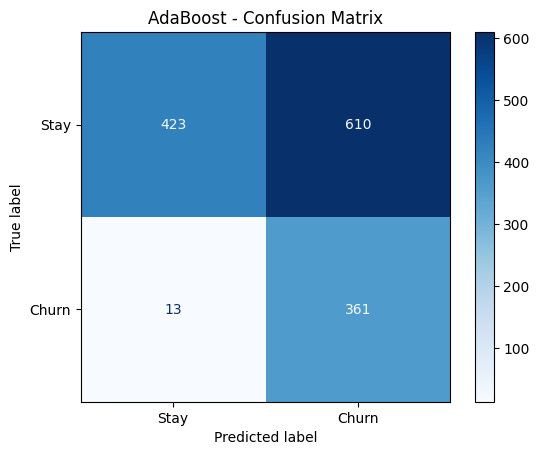

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_proba_ada = best_ada_boost.predict_proba(X_test)[:, 1]
y_predict_ada = (y_proba_ada >= THRESHOLD).astype(int)
cm=confusion_matrix(y_test, y_predict_ada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title('AdaBoost - Confusion Matrix')
plt.show()

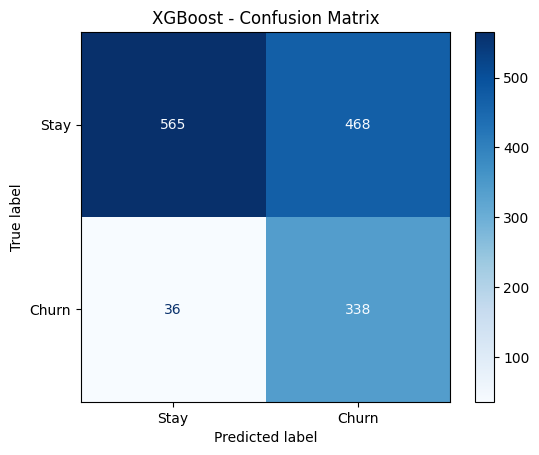

In [59]:
y_proba_xG = best_xG_boost.predict_proba(X_test)[:, 1]
y_predict_xG = (y_proba_xG >= THRESHOLD).astype(int)
cm=confusion_matrix(y_test, y_predict_xG)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title('XGBoost - Confusion Matrix')
plt.show()

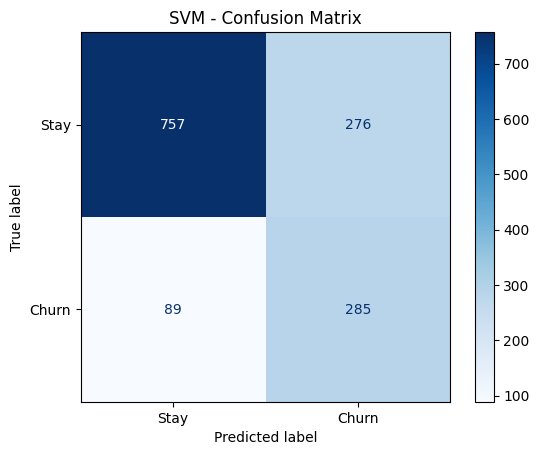

In [60]:
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]
y_predict_svm = (y_proba_svm >= THRESHOLD).astype(int)
cm=confusion_matrix(y_test, y_predict_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title('SVM - Confusion Matrix')
plt.show()


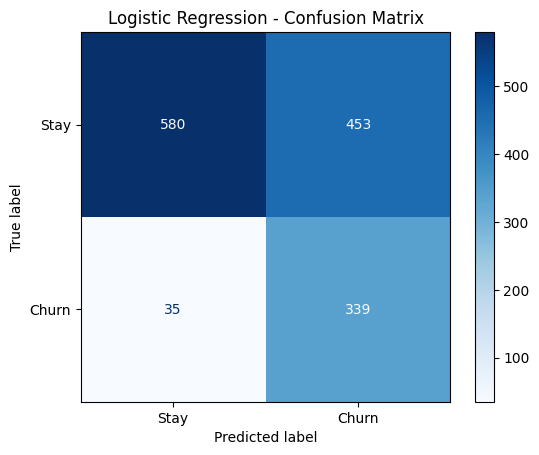

In [61]:
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]
y_predict_lr = (y_proba_lr >= THRESHOLD).astype(int)
cm=confusion_matrix(y_test, y_predict_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

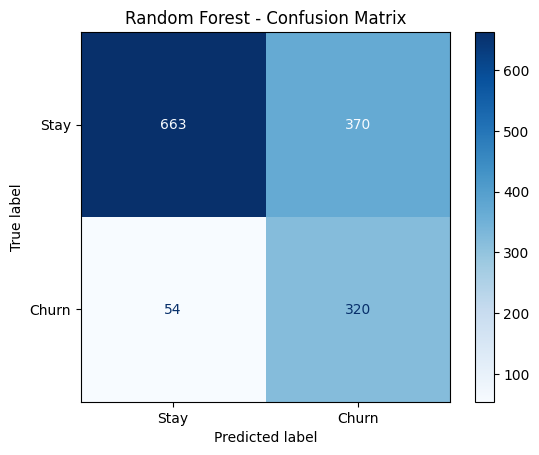

In [62]:
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_predict_rf = (y_proba_rf >= THRESHOLD).astype(int)
cm=confusion_matrix(y_test, y_predict_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title('Random Forest - Confusion Matrix')
plt.show()

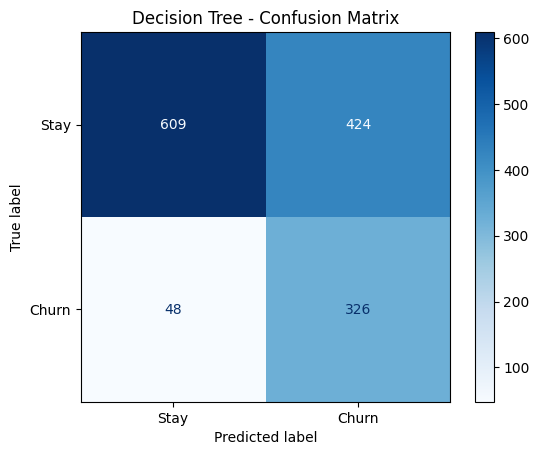

In [63]:
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]
y_predict_dt = (y_proba_dt >= THRESHOLD).astype(int)
cm=confusion_matrix(y_test, y_predict_dt)
disp = ConfusionMatrixDisplay   (confusion_matrix=cm,display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title('Decision Tree - Confusion Matrix')
plt.show()

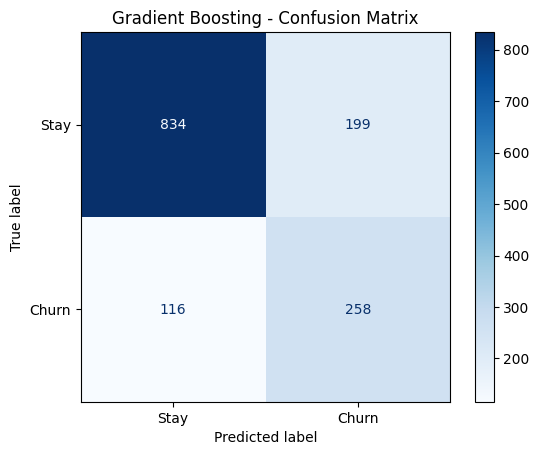

In [64]:
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]
y_predict_gb = (y_proba_gb >= THRESHOLD).astype(int)
cm=confusion_matrix(y_test, y_predict_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Stay', 'Churn'])
disp.plot(cmap="Blues")
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()

### Save Pipelines

In [58]:
import joblib

joblib.dump(best_lr, "logistic_regression_pipeline.pkl")
joblib.dump(best_rf, "random_forest_pipeline.pkl")
joblib.dump(best_svm, "svm_pipeline.pkl")
joblib.dump(best_gb, "gradient_boosting_pipeline.pkl")
joblib.dump(best_dt, "decision_tree_pipeline.pkl")
joblib.dump(best_xG_boost, "xgboost_pipeline.pkl")
joblib.dump(best_ada_boost, "adaboost_pipeline.pkl")

['adaboost_pipeline.pkl']